# Fetal Health Classification
## Objective
The objective of this project is to develop a multiclass model to classify CTG features into the three fetal health states, that is
**Normal**, **Suspect**, and **Pathological**, using features extracted from Cardiotocogram (CTG) examinations.

Cardiotocography is a widely used, non-invasive prenatal monitoring technique that records fetal heart rate and uterine contractions. Early identification of abnormal fetal conditions can help healthcare professionals take timely interventions, reducing the risk of maternal and neonatal complications.

This project evaluates and compares the performance of four classification algorithms:

- K-Nearest Neighbors (KNN)
- Naive Bayes
- Decision Tree
- Random Forest

Dataset taken from Kaggle, Citation:
Ayres de Campos et al. (2000) SisPorto 2.0 A Program for Automated Analysis of Cardiotocograms. J Matern Fetal Med 5:311-318

https://onlinelibrary.wiley.com/doi/10.1002/1520-6661(200009/10)9:5%3C311::AID-MFM12%3E3.0.CO;2-9


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
df=pd.read_csv("fetal_health.csv")
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [9]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(2126, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_va

In [6]:
# 4. Check target distribution

df["fetal_health"].value_counts()

,count
fetal_health,
1.0,1655
2.0,295
3.0,176


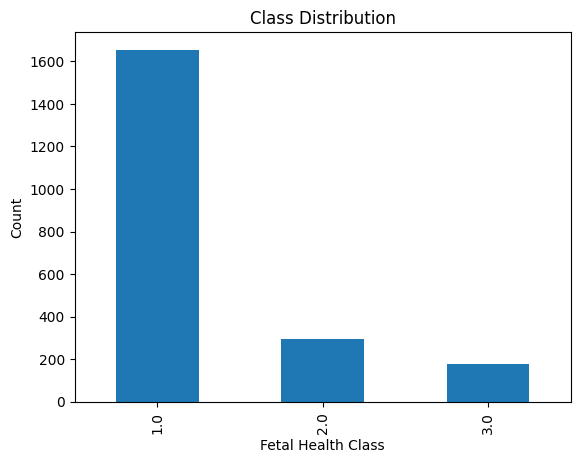

In [10]:
df["fetal_health"].value_counts().plot(kind="bar")
plt.xlabel("Fetal Health Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

##Data Visulization

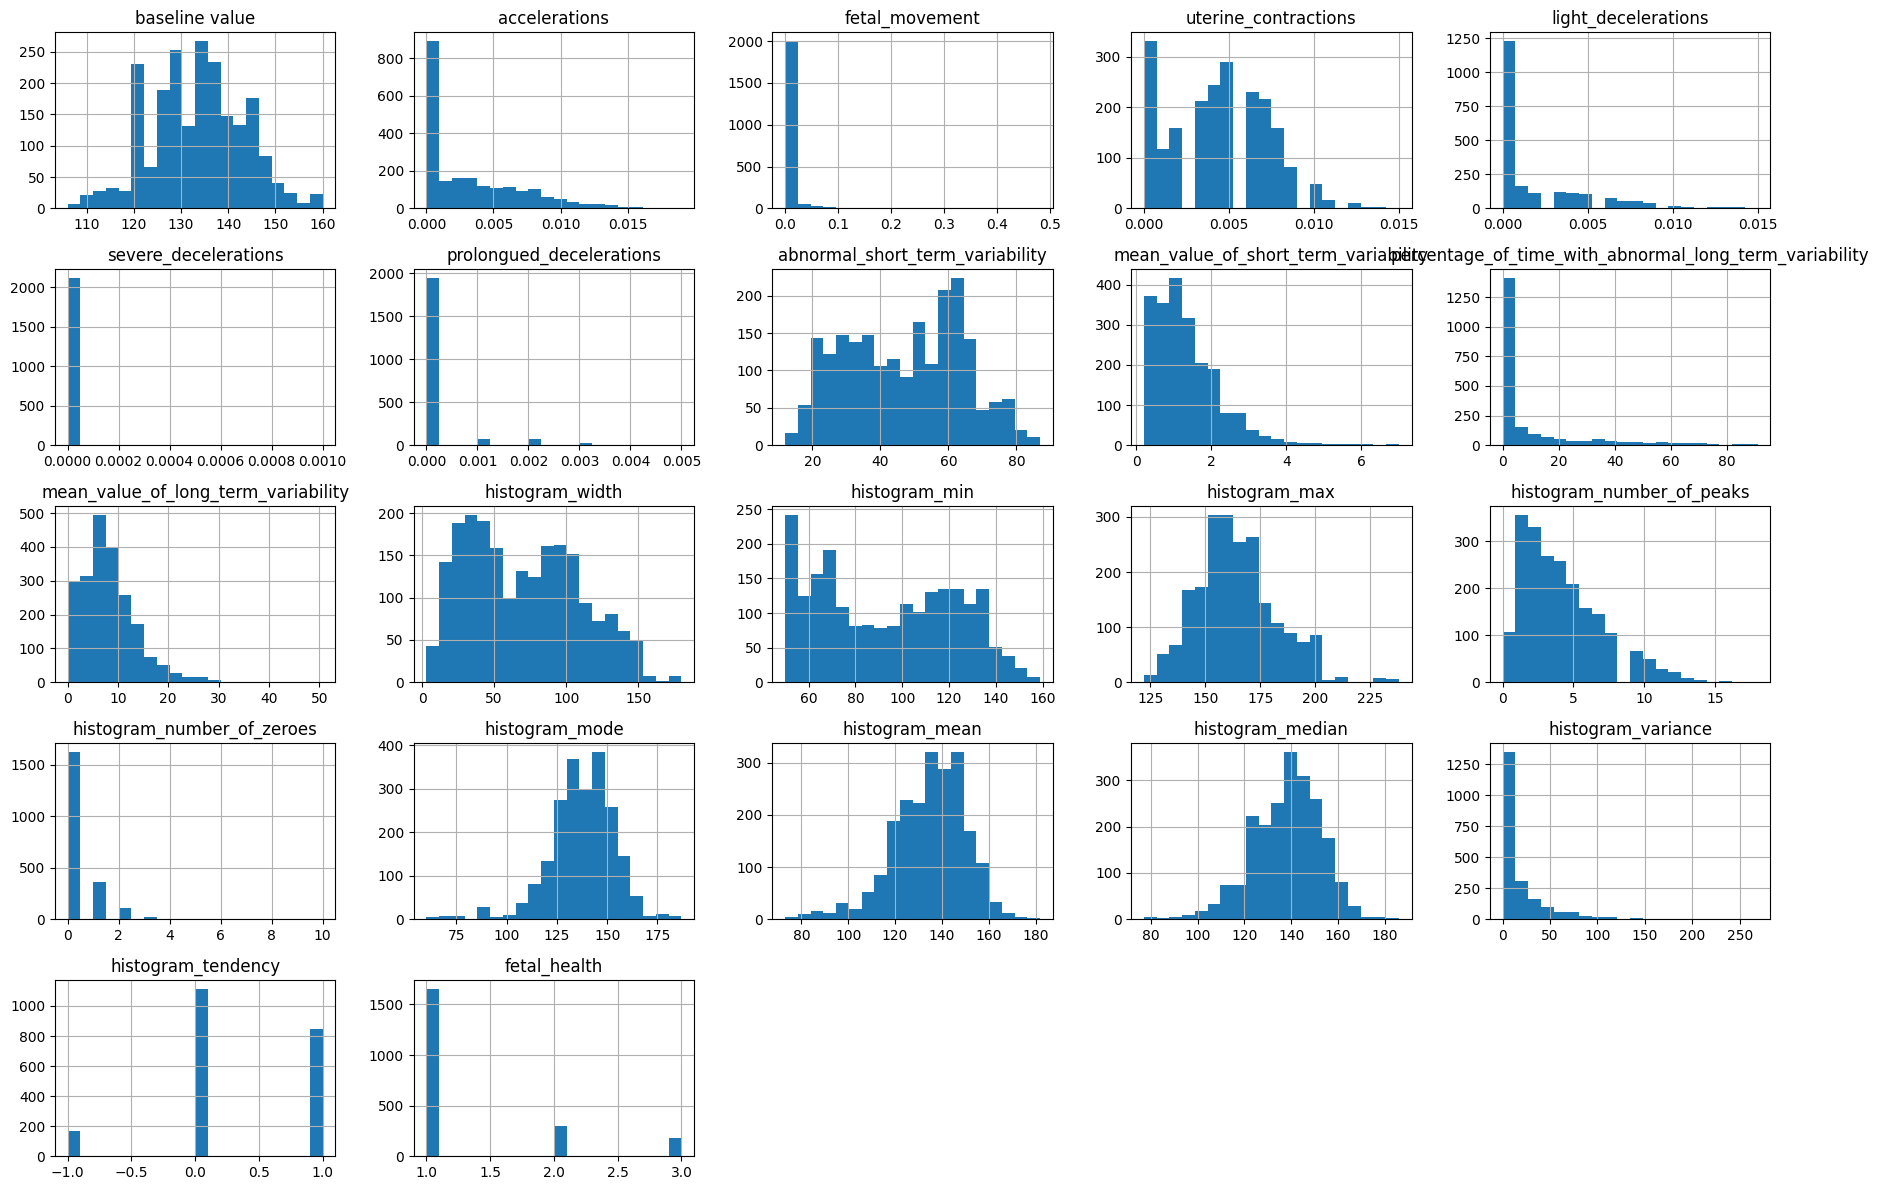

In [11]:
df.hist(
    figsize=(18,12),
    bins=20
)

plt.tight_layout()
plt.show()

##Feature Scaling and Data Splitting

X = Features (Inputs), taking every column except fetal_health.
y = Target (Output), what we want to predict

In [12]:
# Features and Target
# removing target class from dataset

X = df.drop("fetal_health", axis=1)
y = df["fetal_health"].astype(int)

print(X.shape)
print(y.shape)

(2126, 21)
(2126,)


In [13]:
# Dataset splitting

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (1700, 21)
Testing set : (426, 21)


In [27]:
# Using Standard scaler for feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1700, 21)
(426, 21)


##Applying KNN Classifier
We will be using KNN CLassifier for this classification problem and will be using Euclidean distance to select nearest Neighbors.

**Self-Define function:** We will develop our own function to create a KNN CLassfier.

We apply KNN in two ways:

1. Using `KNeighborsClassifier` from scikit-learn.
2. Using GridSearchCV to find the best value of `k`.


In [15]:
# Import KNN and evaluation tools

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

euclidean_distance is to calculate euclidean distance between points.

In [19]:
def euclidean_distance(pt1, pt2):
    return np.sqrt(np.sum((np.array(pt1) - np.array(pt2)) ** 2))

###KNN Prediction Function
distances.append saves how far each training point is from the test point, along with its label.

distances.sort is used to sorts the list so the nearest points come first.

k_nearest_labels picks the labels of the k closest points.

Uses Counter to find which label appears most among those k labels that becomes the prediction.


**Munual KNN Function**

euclidean_distance(): Measures distance between two patients/CTG records.

knn_predict_one(): Predicts the class for one test record.

knn_predict_all(): Predicts the class for all test records.


In [38]:
from collections import Counter
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2)) ** 2))


def knn_predict_one(X_train, y_train, test_point, k):
    distances = []

    for i in range(len(X_train)):
        dist = euclidean_distance(test_point, X_train[i])
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])

    k_nearest_labels = [label for _, label in distances[:k]]

    return Counter(k_nearest_labels).most_common(1)[0][0]

def knn_predict_all(X_train, y_train, X_test, k):
    predictions = []

    for test_point in X_test:
        pred = knn_predict_one(X_train, y_train, test_point, k)
        predictions.append(pred)

    return np.array(predictions)

In [40]:
y_pred_manual_knn = knn_predict_all(
    X_train_scaled,
    y_train.values,
    X_test_scaled,
    k=5
)

In [33]:
print("Manual KNN Accuracy:", accuracy_score(y_test, y_pred_manual_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_manual_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_manual_knn))

Manual KNN Accuracy: 0.8732394366197183

Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.96      0.93       332
           2       0.62      0.49      0.55        59
           3       0.88      0.66      0.75        35

    accuracy                           0.87       426
   macro avg       0.80      0.70      0.75       426
weighted avg       0.86      0.87      0.87       426


Confusion Matrix:
[[320  11   1]
 [ 28  29   2]
 [  5   7  23]]


But how do we know if K value is optimal? We perform GridSearchCV

cv=5 uses 5-fold cross-validation, where the training data is split into 5 parts. It trains on 4 parts and validates on 1 part, repeating this 5 times.

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": range(1, 31),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best Cross-Validation F1 Macro:", grid_knn.best_score_)

print("Best k:", grid_knn.best_params_["n_neighbors"])


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'}
Best Cross-Validation F1 Macro: 0.8434653192992739
Best k: 8


In [43]:
best_knn = grid_knn.best_estimator_

y_pred_best_knn = best_knn.predict(X_test_scaled)

print("Best KNN Accuracy:", accuracy_score(y_test, y_pred_best_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_knn))

Best KNN Accuracy: 0.9084507042253521

Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.97      0.96       332
           2       0.70      0.66      0.68        59
           3       0.90      0.74      0.81        35

    accuracy                           0.91       426
   macro avg       0.85      0.79      0.82       426
weighted avg       0.91      0.91      0.91       426


Confusion Matrix:
[[322   9   1]
 [ 18  39   2]
 [  1   8  26]]
